Dataset link: https://www.kaggle.com/datasets/osamajalilhassan/bone-fracture-dataset/data

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Utility
import seaborn as sns

2026-03-04 18:29:08.965519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772648948.988804     775 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772648948.995419     775 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772648949.012786     775 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772648949.012804     775 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772648949.012807     775 computation_placer.cc:177] computation placer alr

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 2


In [4]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available")
    for gpu in gpus:
        print(gpu)
else:
    print("GPU not detected")

GPU is available
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


In [5]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled


In [6]:
# Dataset Paths

train_fractured_path = "/kaggle/input/datasets/osamajalilhassan/bone-fracture-dataset/BoneFractureDataset/training/fractured"
train_normal_path = "/kaggle/input/datasets/osamajalilhassan/bone-fracture-dataset/BoneFractureDataset/training/not_fractured"

test_fractured_path = "/kaggle/input/datasets/osamajalilhassan/bone-fracture-dataset/BoneFractureDataset/testing/fractured"
test_normal_path = "/kaggle/input/datasets/osamajalilhassan/bone-fracture-dataset/BoneFractureDataset/testing/not_fractured"

In [7]:
# Count training images

train_fractured_count = len(os.listdir(train_fractured_path))
train_normal_count = len(os.listdir(train_normal_path))

# Count testing images

test_fractured_count = len(os.listdir(test_fractured_path))
test_normal_count = len(os.listdir(test_normal_path))

print("TRAINING DATA")
print("Fractured:", train_fractured_count)
print("Not Fractured:", train_normal_count)

print("\nTESTING DATA")
print("Fractured:", test_fractured_count)
print("Not Fractured:", test_normal_count)

print("\nTOTAL IMAGES:",
      train_fractured_count + train_normal_count +
      test_fractured_count + test_normal_count)

TRAINING DATA
Fractured: 4480
Not Fractured: 4383

TESTING DATA
Fractured: 360
Not Fractured: 240

TOTAL IMAGES: 9463


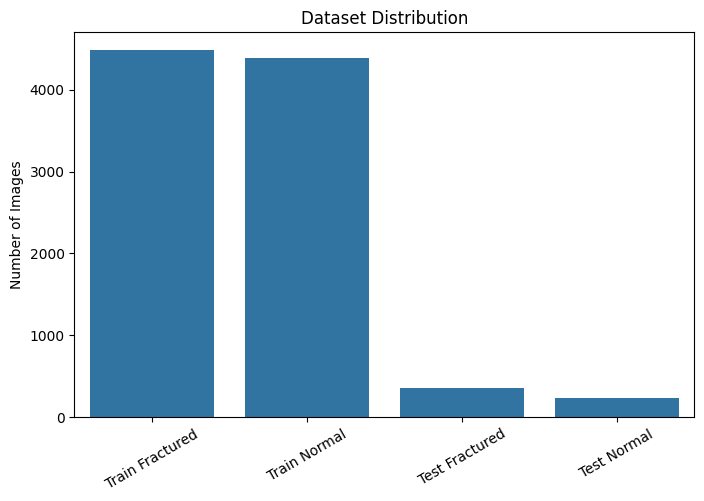

In [8]:
labels = ['Train Fractured','Train Normal','Test Fractured','Test Normal']
counts = [train_fractured_count, train_normal_count, test_fractured_count, test_normal_count]

plt.figure(figsize=(8,5))
sns.barplot(x=labels, y=counts)

plt.title("Dataset Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.show()

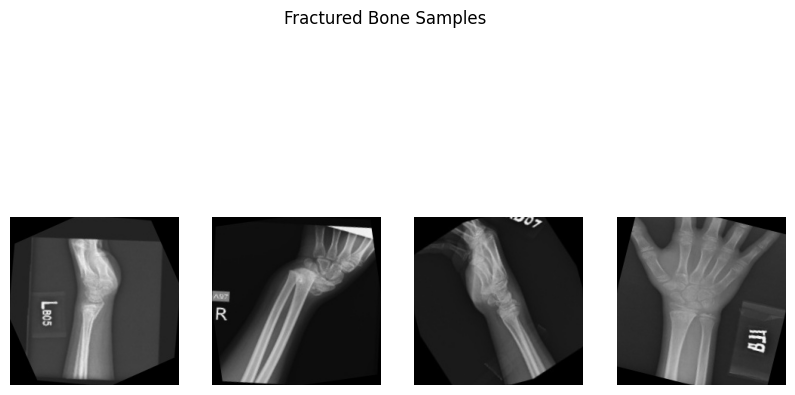

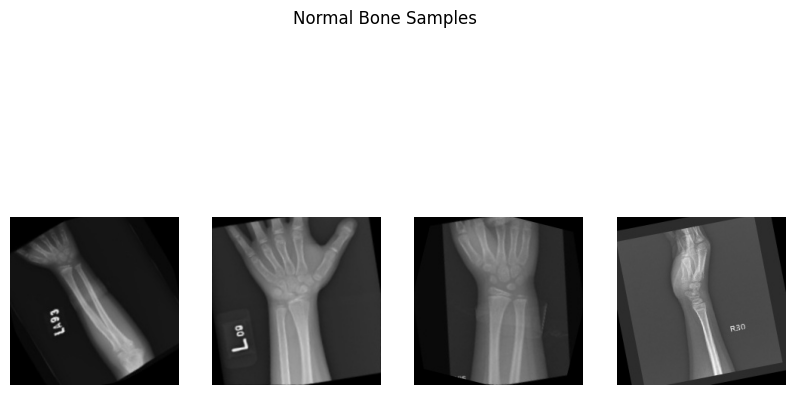

In [9]:
import cv2
import random

def show_samples(folder, title):

    images = os.listdir(folder)
    sample_images = random.sample(images, 4)

    plt.figure(figsize=(10,6))

    for i,img in enumerate(sample_images):

        path = os.path.join(folder,img)
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(1,4,i+1)
        plt.imshow(image)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()


show_samples(train_fractured_path, "Fractured Bone Samples")
show_samples(train_normal_path, "Normal Bone Samples")

In [10]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [11]:
# Image size for ResNet50
IMG_SIZE = (224, 224)

# Batch size
BATCH_SIZE = 32


# Training Data Generator (with augmentation)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=30,
    zoom_range=0.30,

    width_shift_range=0.20,
    height_shift_range=0.20,

    shear_range=0.20,
    horizontal_flip=True,

    brightness_range=[0.8,1.2],

    fill_mode='nearest',

    validation_split=0.2
)


# Testing Data Generator (NO augmentation)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [12]:
train_generator = train_datagen.flow_from_directory(
    
    directory="/kaggle/input/datasets/osamajalilhassan/bone-fracture-dataset/BoneFractureDataset/training",
    
    target_size=IMG_SIZE,
    
    batch_size=BATCH_SIZE,
    
    class_mode="binary",
    
    subset="training"
)

Found 7091 images belonging to 2 classes.


In [13]:
val_generator = train_datagen.flow_from_directory(
    
    directory="/kaggle/input/datasets/osamajalilhassan/bone-fracture-dataset/BoneFractureDataset/training",
    
    target_size=IMG_SIZE,
    
    batch_size=BATCH_SIZE,
    
    class_mode="binary",
    
    subset="validation"
)

Found 1772 images belonging to 2 classes.


In [14]:
test_generator = test_datagen.flow_from_directory(
    
    directory="/kaggle/input/datasets/osamajalilhassan/bone-fracture-dataset/BoneFractureDataset/testing",
    
    target_size=IMG_SIZE,
    
    batch_size=BATCH_SIZE,
    
    class_mode="binary",
    
    shuffle=False
)

Found 600 images belonging to 2 classes.


In [15]:
print("Class Indices:", train_generator.class_indices)

Class Indices: {'fractured': 0, 'not_fractured': 1}


In [16]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

I0000 00:00:1772648961.388473     775 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772648961.393590     775 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [17]:
for layer in base_model.layers:
    layer.trainable = False

In [18]:
from tensorflow.keras.regularizers import l2

In [19]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(x)

x = Dropout(0.6)(x)

x = Dense(
    64,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(x)

x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

In [20]:
model = Model(inputs=base_model.input, outputs=output)

In [21]:
model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,128,769 (92.04 MB)

 Trainable params: 541,057 (2.06 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [24]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_resnet50_fracture_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

callbacks = [early_stop, checkpoint, reduce_lr]

In [25]:
EPOCHS = 20

In [26]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1772648971.337402     871 service.cc:152] XLA service 0x7958f40137f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772648971.337439     871 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772648971.337444     871 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772648973.146696     871 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/222 ━━━━━━━━━━━━━━━━━━━━ 50:15 14s/step - accuracy: 0.4688 - loss: 1.7073

I0000 00:00:1772648978.203719     871 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

222/222 ━━━━━━━━━━━━━━━━━━━━ 113s 511ms/step - accuracy: 0.6560 - loss: 1.1112 - val_accuracy: 0.6332 - val_loss: 1.1059 - learning_rate: 5.0000e-05
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6810 - loss: 1.0591
Epoch 5: val_accuracy improved from 0.63318 to 0.64391, saving model to best_resnet50_fracture_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 114s 512ms/step - accuracy: 0.6810 - loss: 1.0591 - val_accuracy: 0.6439 - val_loss: 1.0773 - learning_rate: 5.0000e-05
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7101 - loss: 1.0230
Epoch 6: val_accuracy improved from 0.64391 to 0.66084, saving model to best_resnet50_fracture_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 115s 517ms/step - accuracy: 0.7101 - loss: 1.0230 - val_accuracy: 0.6608 - val_loss: 1.0495 - learning_rate: 5.0000e-05
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.7220 - loss: 0.9913
Epoch 7: val_accuracy improved from 0.66084 to 0.66648, saving model to best_resnet50_fracture_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 115s 516ms/step - accuracy: 0.7220 - loss: 0.9913 - val_accuracy: 0.6665 - val_loss: 1.0323 - learning_rate: 5.0000e-05
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.7429 - loss: 0.9565
Epoch 8: val_accuracy improved from 0.66648 to 0.67889, saving model to best_resnet50_fracture_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 115s 516ms/step - accuracy: 0.7429 - loss: 0.9565 - val_accuracy: 0.6789 - val_loss: 1.0090 - learning_rate: 5.0000e-05
Epoch 9/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7680 - loss: 0.9121
Epoch 9: val_accuracy did not improve from 0.67889
222/222 ━━━━━━━━━━━━━━━━━━━━ 115s 517ms/step - accuracy: 0.7679 - loss: 0.9121 - val_accuracy: 0.6778 - val_loss: 0.9954 - learning_rate: 5.0000e-05
Epoch 10/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7776 - loss: 0.8929
Epoch 10: val_accuracy did not improve from 0.67889
222/222 ━━━━━━━━━━━━━━━━━━━━ 114s 511ms/step - accuracy: 0.7776 - loss: 0.8928 - val_accuracy: 0.6755 - val_loss: 0.9825 - learning_rate: 5.0000e-05
Epoch 11/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.7821 - loss: 0.8582
Epoch 11: val_accuracy did not improve from 0.67889
222/222 ━━━━━━━━━━━━━━━━━━━━ 113s 508ms/step - accuracy: 0.7822 - loss: 0.8582 - val_accuracy: 0.6586 - val_loss: 0.9939 - learning_

In [27]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 334ms/step - accuracy: 0.6402 - loss: 0.9451
Test Loss: 0.8959177732467651
Test Accuracy: 0.6916666626930237


In [28]:
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

y_true = test_generator.classes

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step


In [29]:
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=['Fractured','Not Fractured']
))

Classification Report:

               precision    recall  f1-score   support

    Fractured       0.82      0.62      0.71       360
Not Fractured       0.58      0.80      0.67       240

     accuracy                           0.69       600
    macro avg       0.70      0.71      0.69       600
 weighted avg       0.73      0.69      0.69       600



In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[223 137]
 [ 48 192]]


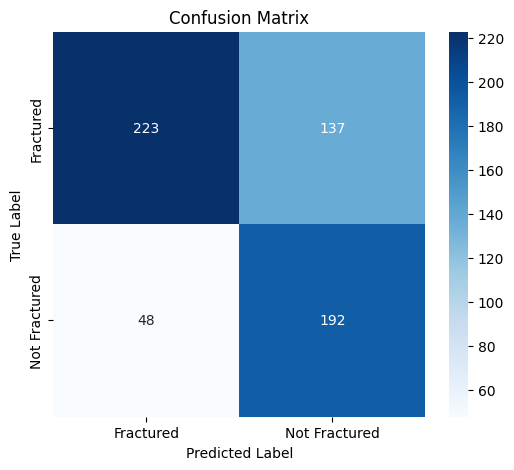

In [31]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fractured','Not Fractured'],
    yticklabels=['Fractured','Not Fractured']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, predictions)

In [33]:
from sklearn.metrics import auc

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.7875231481481482


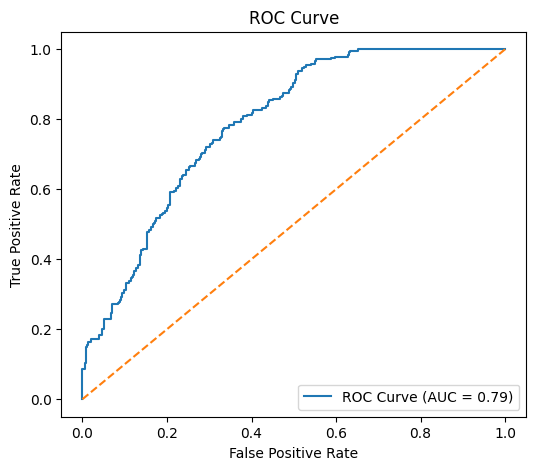

In [34]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

In [35]:
model.save("bone_fracture_resnet50_model.keras")